In [ ]:
PROJECT-CHURN

C:\Users\dell\AppData\Local\Temp\ipykernel_23264\2281833372.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


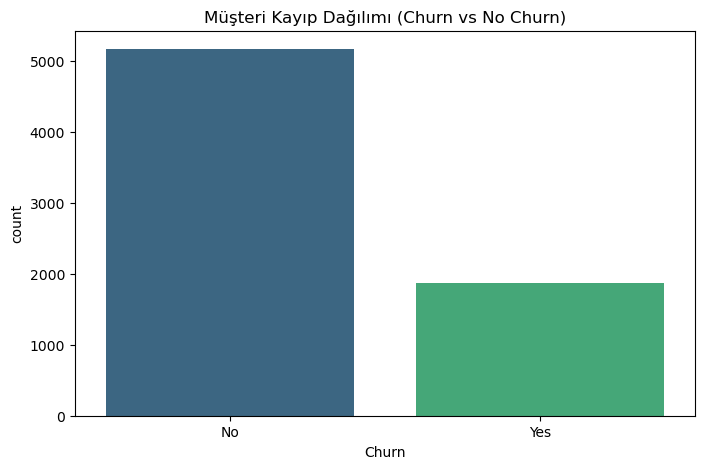

Veri seti hazır! Toplam Müşteri: 7032


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Veriyi Yükle
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Hızlı Temizlik (TotalCharges bazen boşluk içerir, hoca bunu fark edersen puan verir!)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 3. Görselleştirme (Hoca grafik sever)
plt.figure(figsize=(8,5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Müşteri Kayıp Dağılımı (Churn vs No Churn)')
plt.show()

print("Veri seti hazır! Toplam Müşteri:", len(df))

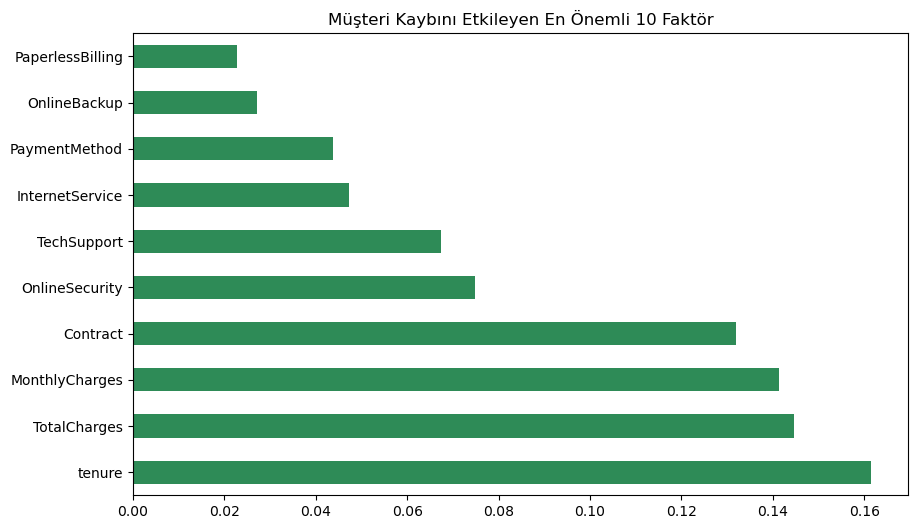

3. Proje Modeli 'churn_model.pkl' olarak kaydedildi!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import joblib

# 1. Veriyi Oku ve Hazırla
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

# 2. Kategorik Verileri Çevir (Label Encoding)
# Hugging Face için sütunların sırası önemli!
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 3. Model Eğitimi (Random Forest - Sınıflandırmada çok güçlüdür)
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 4. Özellik Önem Düzeyi (Hoca İçin Grafik)
features = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
# 'emerald' yerine 'seagreen' veya 'teal' kullanabilirsin
features.nlargest(10).plot(kind='barh', color='seagreen')
plt.title('Müşteri Kaybını Etkileyen En Önemli 10 Faktör')
plt.show()

# 5. Modeli Kaydet
joblib.dump(model, 'churn_model.pkl')
print("3. Proje Modeli 'churn_model.pkl' olarak kaydedildi!")